## 1. Analysis Objective

This analysis investigates relationships that may provide deeper insight into appointment outcomes beyond the descriptive patterns identified during exploratory analysis.

The analysis focuses on:

- booking lead time and no-show behaviour
- previous no-show history and subsequent appointment outcomes
- the combined effect of booking lead time and previous no-show history

The objective is to identify meaningful patterns and higher-risk appointment segments that can support more targeted operational interventions.

In [1]:
# Load cleaned Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../healthconnect_cleaned.csv",
    parse_dates=["booking_date", "appointment_date"]
)

df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,distance_missing,waiting_missing
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-02-06,2025-02-18,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show,False,False
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2026-02-25,2026-02-27,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended,False,False
2,HC-00003,P-1366,Female,50,45-54,General Consultation,2025-11-16,2025-12-24,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show,False,False
3,HC-00004,P-1031,Male,59,55-64,Follow-up,2025-07-18,2025-08-28,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended,False,False
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-07-09,2025-08-25,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show,False,False


## 2. Booking Lead Time Analysis

### 2.1 Lead Time Distribution

Booking lead time represents the number of days between the booking date and the scheduled appointment date.

The distribution is examined to understand how far in advance appointments are typically scheduled and whether the dataset contains sufficient observations across different lead-time periods.

In [7]:
df["booking_lead_days"].describe()

count    5000.00000
mean       29.63860
std        17.39936
min         0.00000
25%        15.00000
50%        30.00000
75%        45.00000
max        60.00000
Name: booking_lead_days, dtype: float64

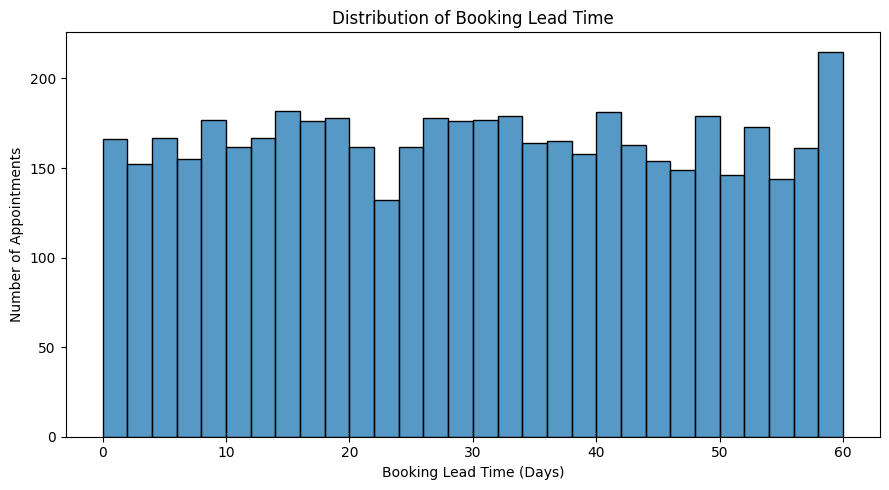

In [8]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="booking_lead_days",
    bins=30
)

plt.title("Distribution of Booking Lead Time")
plt.xlabel("Booking Lead Time (Days)")
plt.ylabel("Number of Appointments")
plt.tight_layout()
plt.show()

### 2.2 Lead Time Groups

Booking lead time is grouped into operationally meaningful periods to make differences in appointment outcomes easier to compare.

In [9]:
lead_time_bins = [-1, 2, 7, 14, 30, float("inf")]

lead_time_labels = [
    "0–2 days",
    "3–7 days",
    "8–14 days",
    "15–30 days",
    "31+ days"
]

df["booking_lead_group"] = pd.cut(
    df["booking_lead_days"],
    bins=lead_time_bins,
    labels=lead_time_labels
)

lead_time_distribution = (
    df["booking_lead_group"]
    .value_counts()
    .reindex(lead_time_labels)
)

lead_time_distribution

booking_lead_group
0–2 days       244
3–7 days       396
8–14 days      602
15–30 days    1333
31+ days      2425
Name: count, dtype: int64

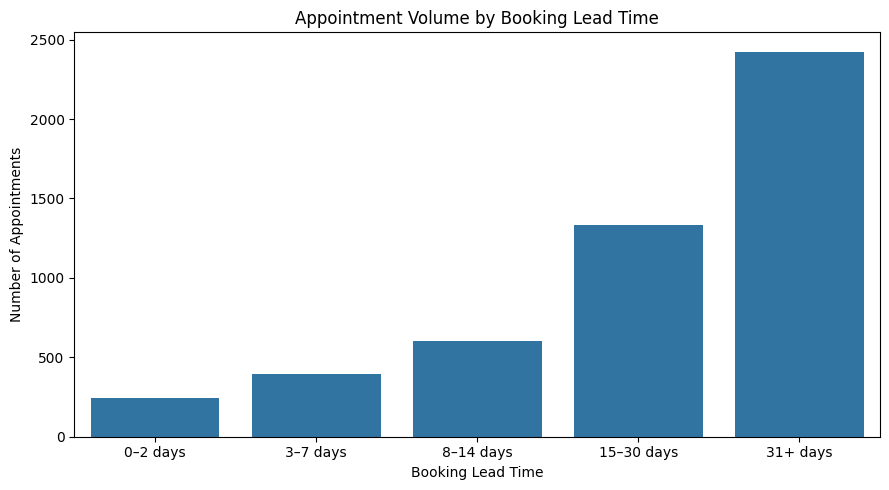

In [10]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="booking_lead_group",
    order=lead_time_labels
)

plt.title("Appointment Volume by Booking Lead Time")
plt.xlabel("Booking Lead Time")
plt.ylabel("Number of Appointments")
plt.tight_layout()
plt.show()

### 2.3 No-Show Rate by Lead Time

No-show rates are compared across booking lead-time groups to examine whether appointment attendance varies according to how far in advance appointments are booked.

In [11]:
lead_time_no_show = (
    df.groupby("booking_lead_group", observed=False)["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .reindex(lead_time_labels)
    .reset_index(name="no_show_rate")
)

lead_time_no_show

,booking_lead_group,no_show_rate
0,0–2 days,24.180328
1,3–7 days,30.050505
2,8–14 days,33.554817
3,15–30 days,43.210803
4,31+ days,60.494845


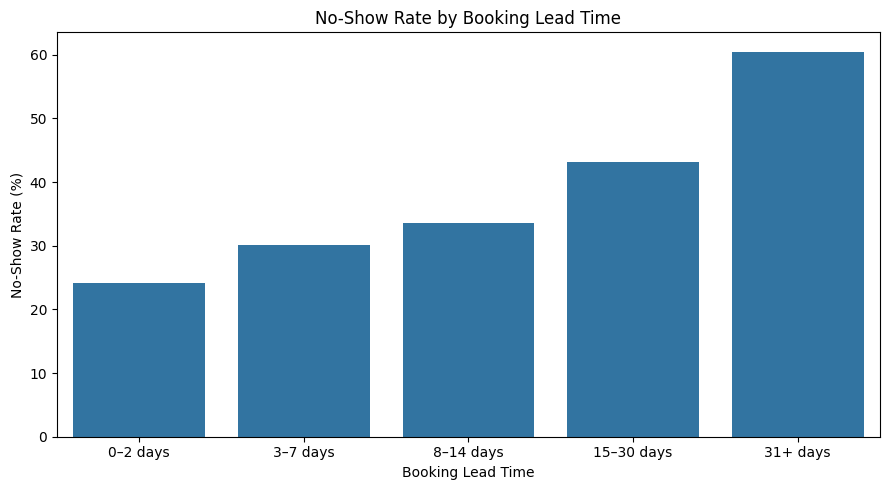

In [12]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=lead_time_no_show,
    x="booking_lead_group",
    y="no_show_rate"
)

plt.title("No-Show Rate by Booking Lead Time")
plt.xlabel("Booking Lead Time")
plt.ylabel("No-Show Rate (%)")
plt.tight_layout()
plt.show()

> **Interpretation:** No-show rates increased consistently with booking lead time, rising from approximately **24%** for appointments booked 0–2 days in advance to approximately **60%** for appointments booked 31+ days in advance. This pattern indicates that booking lead time is an important variable to consider when examining appointment attendance behaviour.

## 3. Previous No-Show Behaviour

### 3.1 Previous No-Shows and Current Outcomes

Previous no-show history is examined to determine whether patients with a history of missed appointments show different outcome patterns for subsequent appointments.

In [13]:
previous_no_show_outcomes = pd.crosstab(
    df["previous_no_shows"],
    df["appointment_outcome"],
    normalize="index"
) * 100

previous_no_show_outcomes

appointment_outcome,Attended,Cancelled,No-Show
previous_no_shows,,,
0,50.462170,6.025334,43.512496
1,42.248062,4.263566,53.488372
2,36.301370,4.337900,59.360731
3,29.487179,2.564103,67.948718
4,33.333333,0.000000,66.666667
5,0.000000,0.000000,100.000000


In [37]:
previous_no_show_summary = (
    df.groupby("previous_no_shows")
      .agg(
          appointments=("appointment_id", "count"),
          no_show_rate=("appointment_outcome",
                        lambda x: (x == "No-Show").mean() * 100)
      )
      .reset_index()
)

previous_no_show_summary

,previous_no_shows,appointments,no_show_rate
0,0,2921,43.512496
1,1,1548,53.488372
2,2,438,59.360731
3,3,78,67.948718
4,4,12,66.666667
5,5,3,100.000000


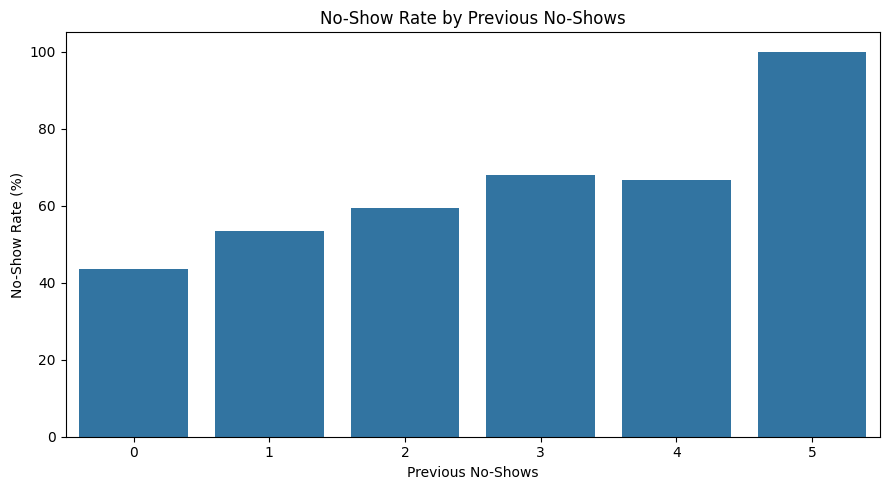

In [38]:
previous_no_show_rate = (
    df.groupby("previous_no_shows")["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .reset_index(name="no_show_rate")
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=previous_no_show_rate,
    x="previous_no_shows",
    y="no_show_rate"
)

plt.title("No-Show Rate by Previous No-Shows")
plt.xlabel("Previous No-Shows")
plt.ylabel("No-Show Rate (%)")
plt.tight_layout()
plt.show()

> **Interpretation:** Patients with previous no-shows generally recorded higher current no-show rates. This indicates that previous attendance behaviour provides useful information when examining subsequent appointment outcomes, although it should not be considered in isolation.

## 4. Combined Risk Patterns

### 4.1 Lead Time × Previous No-Shows

Booking lead time and previous no-show history are examined together to identify combinations associated with comparatively higher observed no-show rates.

In [16]:
risk_segment = (
    df.groupby(
        ["previous_no_shows", "booking_lead_group"],
        observed=False
    )
    .agg(
        appointments=("appointment_id", "count"),
        no_shows=("appointment_outcome", lambda x: (x == "No-Show").sum())
    )
    .reset_index()
)

risk_segment["no_show_rate"] = (
    risk_segment["no_shows"] /
    risk_segment["appointments"] * 100
)

risk_segment

,previous_no_shows,booking_lead_group,appointments,no_shows,no_show_rate
0,0,0–2 days,146,26.0,17.808219
1,0,3–7 days,226,55.0,24.336283
2,0,8–14 days,376,119.0,31.648936
3,0,15–30 days,763,293.0,38.401048
4,0,31+ days,1410,778.0,55.177305
5,1,0–2 days,69,21.0,30.434783
6,1,3–7 days,121,42.0,34.710744
7,1,8–14 days,157,50.0,31.847134
8,1,15–30 days,419,196.0,46.778043
9,1,31+ days,782,519.0,66.368286


In [17]:
risk_matrix = risk_segment.pivot(
    index="previous_no_shows",
    columns="booking_lead_group",
    values="no_show_rate"
)

risk_matrix

booking_lead_group,0–2 days,3–7 days,8–14 days,15–30 days,31+ days
previous_no_shows,,,,,
0,17.808219,24.336283,31.648936,38.401048,55.177305
1,30.434783,34.710744,31.847134,46.778043,66.368286
2,46.153846,51.351351,45.762712,52.800000,71.204188
3,0.000000,27.272727,50.000000,85.714286,80.000000
4,NaN,0.000000,100.000000,60.000000,80.000000
5,NaN,NaN,100.000000,NaN,100.000000


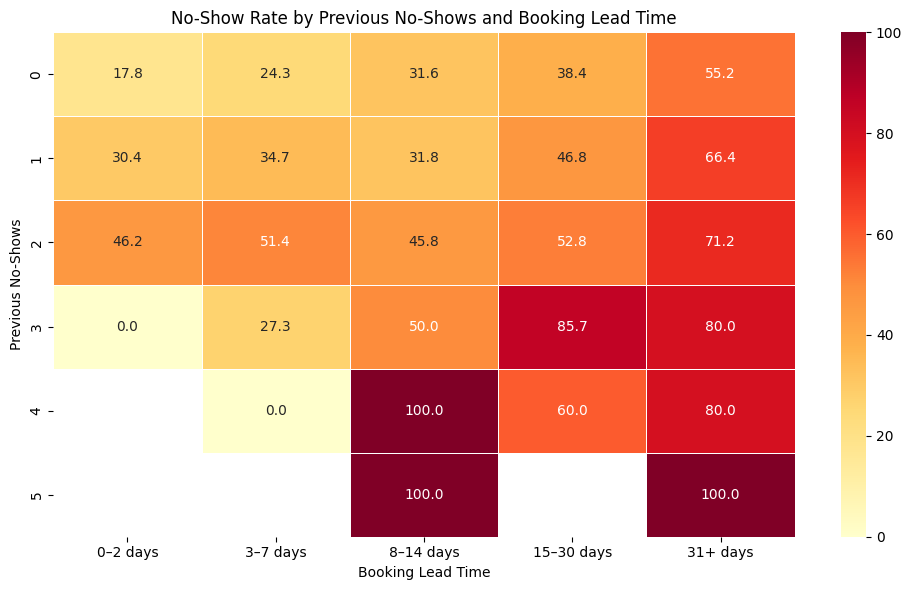

In [18]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    risk_matrix,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("No-Show Rate by Previous No-Shows and Booking Lead Time")
plt.xlabel("Booking Lead Time")
plt.ylabel("Previous No-Shows")
plt.tight_layout()
plt.show()

### 4.2 Higher-Risk Segments

The combined analysis is used to identify appointment segments with comparatively high observed no-show rates.

These segments represent analytical patterns rather than formal predictive risk classifications.

In [23]:
higher_risk_segments = (
    risk_segment[
        risk_segment["appointments"] >= 100
    ]
    .sort_values("no_show_rate", ascending=False)
)

higher_risk_segments

,previous_no_shows,booking_lead_group,appointments,no_shows,no_show_rate
14,2,31+ days,191,136.0,71.204188
9,1,31+ days,782,519.0,66.368286
4,0,31+ days,1410,778.0,55.177305
13,2,15–30 days,125,66.0,52.800000
8,1,15–30 days,419,196.0,46.778043
3,0,15–30 days,763,293.0,38.401048
6,1,3–7 days,121,42.0,34.710744
7,1,8–14 days,157,50.0,31.847134
2,0,8–14 days,376,119.0,31.648936
1,0,3–7 days,226,55.0,24.336283


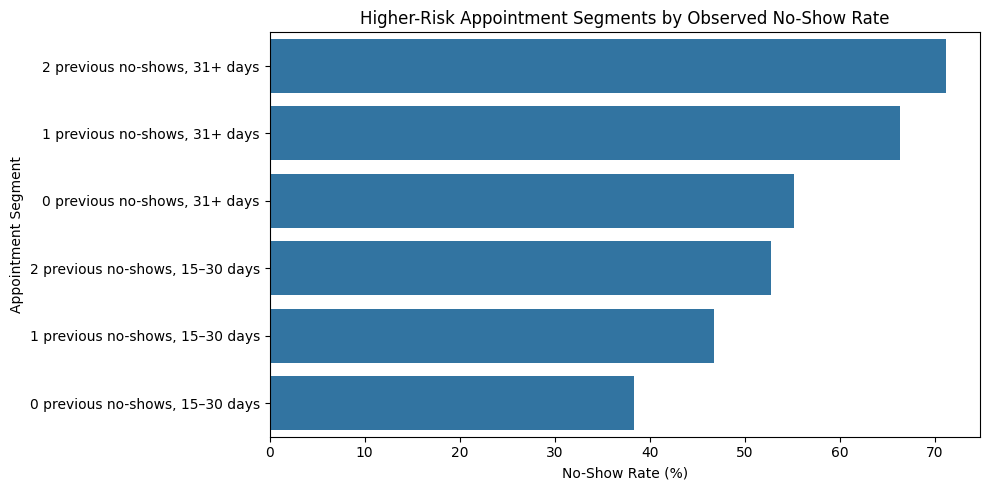

In [24]:
top_segments = higher_risk_segments.head(6).copy()

top_segments["segment"] = (
    top_segments["previous_no_shows"].astype(str)
    + " previous no-shows, "
    + top_segments["booking_lead_group"].astype(str)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_segments,
    x="no_show_rate",
    y="segment"
)

plt.title("Higher-Risk Appointment Segments by Observed No-Show Rate")
plt.xlabel("No-Show Rate (%)")
plt.ylabel("Appointment Segment")
plt.tight_layout()
plt.show()

> **Interpretation:** Higher observed no-show rates were concentrated among appointments with longer booking lead times and previous no-show history. However, appointments with no previous no-shows also showed elevated no-show rates when booked 31+ days in advance, indicating that booking lead time provides additional information beyond previous attendance history alone. Some cells involving higher numbers of previous no-shows are based on relatively small appointment volumes and should therefore be interpreted cautiously.

## 5. Reminder Analysis

### 5.1 Reminder Coverage by Lead Time

Reminder coverage is examined across booking lead-time groups to determine whether differences in reminder coverage could help explain the variation in no-show rates observed across lead times.

In [25]:
reminder_coverage = (
    pd.crosstab(
        df["booking_lead_group"],
        df["reminder_channel"],
        normalize="index"
    ) * 100
)

reminder_coverage

reminder_channel,Email,No reminder,SMS,WhatsApp
booking_lead_group,,,,
0–2 days,12.295082,28.278689,41.393443,18.032787
3–7 days,13.888889,24.747475,41.666667,19.696970
8–14 days,11.627907,26.744186,41.528239,20.099668
15–30 days,8.477119,28.357089,41.785446,21.380345
31+ days,10.927835,27.216495,38.226804,23.628866


In [26]:
# no-reminder rate
no_reminder_by_lead = (
    df.groupby("booking_lead_group", observed=False)["reminder_channel"]
    .apply(lambda x: (x == "No reminder").mean() * 100)
    .reindex(lead_time_labels)
    .reset_index(name="no_reminder_rate")
)

no_reminder_by_lead

,booking_lead_group,no_reminder_rate
0,0–2 days,28.278689
1,3–7 days,24.747475
2,8–14 days,26.744186
3,15–30 days,28.357089
4,31+ days,27.216495


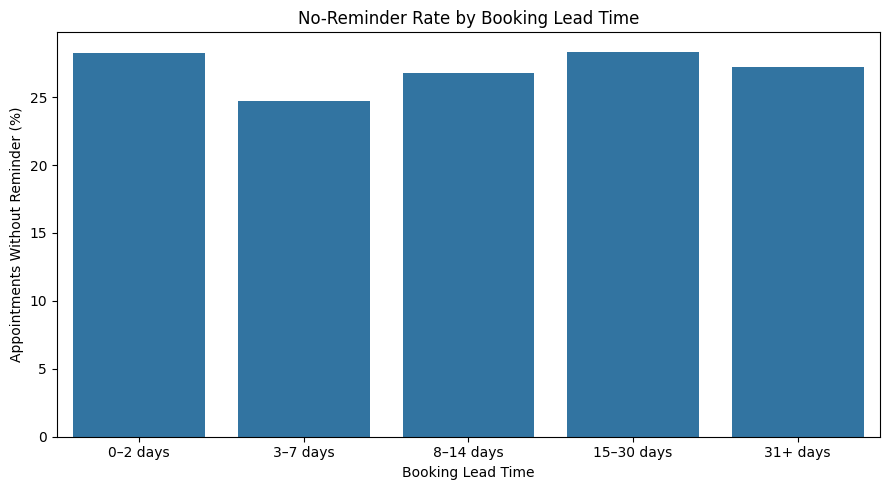

In [27]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=no_reminder_by_lead,
    x="booking_lead_group",
    y="no_reminder_rate"
)

plt.title("No-Reminder Rate by Booking Lead Time")
plt.xlabel("Booking Lead Time")
plt.ylabel("Appointments Without Reminder (%)")
plt.tight_layout()
plt.show()

### 5.2 Reminder Outcome Comparison in Higher-Risk Segments

Reminder outcomes are examined within the higher-risk appointment segments identified earlier.

This comparison focuses on observed differences between reminder statuses and channels rather than treating the results as evidence of a causal effect.

In [28]:
higher_risk_mask = (
    (df["booking_lead_days"] >= 31) |
    (
        (df["previous_no_shows"] >= 1) &
        (df["booking_lead_days"] >= 15)
    )
)

high_risk_reminders = df[higher_risk_mask].copy()

reminder_effectiveness = (
    pd.crosstab(
        high_risk_reminders["reminder_channel"],
        high_risk_reminders["appointment_outcome"],
        normalize="index"
    ) * 100
)

reminder_effectiveness

appointment_outcome,Attended,Cancelled,No-Show
reminder_channel,,,
Email,36.875000,3.437500,59.687500
No reminder,32.972323,5.415162,61.612515
SMS,39.948007,4.679376,55.372617
WhatsApp,35.217391,5.652174,59.130435


In [29]:
high_risk_no_show = (
    high_risk_reminders
    .groupby("reminder_channel")["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .reset_index(name="no_show_rate")
    .sort_values("no_show_rate")
)

high_risk_no_show

,reminder_channel,no_show_rate
2,SMS,55.372617
3,WhatsApp,59.130435
0,Email,59.687500
1,No reminder,61.612515


> **Interpretation:** Within the higher-risk segments, appointments without a recorded reminder had the highest observed no-show rate at approximately **61%**, while SMS had the lowest at approximately **55%** among the recorded reminder channels. The differences between reminder channels were relatively modest, so the findings support examining reminder coverage and targeted intervention rather than assuming that one channel is universally more effective.

## 6. Statistical Validation

### 6.1 Booking Lead Time × Appointment Outcome

A chi-square test of independence is used to determine whether booking lead-time group and appointment outcome are statistically associated.

In [30]:
from scipy.stats import chi2_contingency

lead_time_contingency = pd.crosstab(
    df["booking_lead_group"],
    df["appointment_outcome"]
)

chi2_lead, p_lead, dof_lead, expected_lead = chi2_contingency(
    lead_time_contingency
)

chi2_lead, p_lead, dof_lead

(np.float64(341.1203533675732), np.float64(7.108845471838108e-69), 8)

### 6.2 Previous No-Shows × Appointment Outcome

A chi-square test of independence is used to assess whether previous no-show history and current appointment outcome are statistically associated.

In [31]:
previous_no_show_contingency = pd.crosstab(
    df["previous_no_shows"],
    df["appointment_outcome"]
)

chi2_previous, p_previous, dof_previous, expected_previous = (
    chi2_contingency(previous_no_show_contingency)
)

chi2_previous, p_previous, dof_previous

(np.float64(83.3757153469355), np.float64(1.0906187436066216e-13), 10)

### 6.3 Effect Size Interpretation

Statistical significance is considered alongside effect size to assess the practical strength of the observed relationships.

Cramér's V is used for both categorical comparisons.

In [32]:
import numpy as np

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()
    r, k = confusion_matrix.shape

    return np.sqrt(
        (chi2 / n) /
        min(k - 1, r - 1)
    )

cramers_v_lead = cramers_v(lead_time_contingency)
cramers_v_previous = cramers_v(previous_no_show_contingency)

print(f"Booking lead time: Cramér's V = {cramers_v_lead:.3f}")
print(f"Previous no-shows: Cramér's V = {cramers_v_previous:.3f}")

Booking lead time: Cramér's V = 0.185
Previous no-shows: Cramér's V = 0.091


> **Interpretation:** Both relationships are statistically significant (p < 0.001). However, the effect sizes indicate that the relationships are modest for booking lead time and relatively weak for previous no-show history. Statistical significance therefore should not be interpreted as evidence of a strong practical effect.

## 7. Cross-Track Validation

### 7.1 Analytical Findings vs Data Science Model

The validated analytical findings were used as inputs for Data Science modelling of appointment no-show behaviour.

The main analytical inputs included:

- Booking lead time, which showed a modest association with appointment outcomes (Cramér's V = 0.185).
- Previous no-show history, which showed a weaker association with appointment outcomes (Cramér's V = 0.091).
- Higher-risk appointment segments identified from combinations of booking lead time and previous no-show history.
- Reminder coverage, with approximately 27% of appointments having no recorded reminder.
- Reminder channel patterns within higher-risk segments.

The modelling results were broadly consistent with the analytical findings, while also providing additional information about the predictive contribution of reminder variables.

### 7.2 Multicollinearity Check

The initial model included multiple variables describing previous appointment history, including `previous_appointments`, `previous_no_shows`, and `previous_no_show_rate`.

These variables contain overlapping information because `previous_no_show_rate` is derived from previous appointment and no-show counts. The resulting VIF values indicated moderate multicollinearity.

To improve interpretability, the raw history counts were removed and `previous_no_show_rate` was retained as the summary measure of previous no-show behaviour.

### 7.3 Model Refinement

The refined model retained:

- `booking_lead_days`
- `previous_no_show_rate`
- `is_new_patient`
- `reminder_sent`
- `reminder_channel`

Removing the overlapping previous-history variables corrected the direction of the `previous_no_show_rate` coefficient while producing virtually unchanged predictive performance.

The analysis also found that reminder variables provided additional predictive information beyond booking lead time and patient history (likelihood-ratio test = 11.53, df = 3, p = 0.0092).

An explicit interaction between previous no-show rate and booking lead time provided minimal additional predictive value and was therefore not retained.

### 7.4 Retest Results

The refined model was re-evaluated after the feature changes to confirm that the multicollinearity issue had been addressed without materially reducing predictive performance.

The candidate models produced ROC-AUC values around 0.68–0.69, with the interaction model providing only a negligible improvement over the additive model.

The refined model therefore provides a more interpretable representation of previous no-show behaviour without a meaningful loss in predictive performance.

The resulting model is best treated as a risk-ranking or triage tool to support operational prioritisation rather than as an automated decision-making system.

## 8. Advanced Analysis Summary

The advanced analysis identified several consistent patterns in appointment attendance:

- No-show rates increased substantially with longer booking lead times.
- Previous no-show history was associated with higher current no-show rates.
- Combining booking lead time with previous no-show history revealed distinct higher-risk appointment segments.
- Reminder coverage remained relatively consistent across lead-time groups, while appointments without recorded reminders showed higher observed no-show rates within the higher-risk segments.
- Statistical testing confirmed significant associations between booking lead time, previous no-shows, and appointment outcomes, although effect sizes were modest to weak.
- Cross-track validation supported the analytical findings while identifying and addressing multicollinearity among previous appointment-history variables.

These findings provide the analytical basis for the recommendations and proposed operational interventions presented in the HealthConnect executive summary.